# Лабораторная работа 7. Полносвязные нейронные сети (FCNN). Решение задачи классификации

## Загрузка данных и понижение размерности

Прежде, чем работать с данными, применим к ним стандартизацию. Отметим, что в ходе EDA к данным была применено MinMax масштабирование, но дополнительная стандартизация существенно влияет на производительность при обучении нейронных сетей.

После этого применим понижение размерности данных при помощи UMAP. С помощью этого алгоритма на основе предыдущих признаков будут построены 3 новых, тем самым понизив признаковое пространство с 5 исходных признаков до 3.

Следующим этапом применим RandomUnder-сэмплирование. Эта стретегия балансировки классов подразумевает удаление экземпляров мажоритарного класса. Тем самым будет произведена балансировка классов и уменьшено общее количество объектов, что благоприятно для обучения нейронных сетей.

In [2]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.model_selection import train_test_split
from umap import UMAP
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

import optuna

from tensorflow import keras
from tensorflow.keras import layers

data = pd.read_csv("datasets/neo.csv", index_col = 0)

X, y = data.drop("hazardous", axis=1), data["hazardous"]

X = StandardScaler().fit_transform(X)

umap = UMAP(n_components=3, random_state=42)
X = umap.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)

X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [3]:
X_train_res.shape

(21216, 3)

Видим, что количество объектов уменьшилось до 21216.

## FCNN (MLP) из библиотеки Scikit-learn

In [4]:
columns = [
    'Classifier', 'Search strategy',
    'Train_F1', 'Train_Accuracy', 'Train_Precision', 'Train_Recall',
    'Test_F1', 'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Epochs', 'Solver'
]
table = pd.DataFrame(columns=columns)
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver


In [5]:
def input_into_table(name, search_name, model, X_train, y_train, X_test, y_test):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    new_row = {
        'Classifier': name,
        'Search strategy': search_name,
        'Train_F1': round(f1_score(y_train, train_pred), 2),
        'Train_Accuracy': round(accuracy_score(y_train, train_pred), 4),
        'Train_Precision': round(precision_score(y_train, train_pred), 4),
        'Train_Recall': round(recall_score(y_test, test_pred), 4),
        'Test_F1': round(f1_score(y_test, test_pred), 2),
        'Test_Accuracy': round(accuracy_score(y_test, test_pred), 4),
        'Test_Precision': round(precision_score(y_test, test_pred), 4),
        'Test_Recall': round(recall_score(y_test, test_pred), 4),
        'Epochs': model.n_iter_,
        'Solver': model.solver
    }

    table.loc[len(table)] = new_row

### Optuna

Отметим, какие гиперпараметры будут настраиваться в ходе подбора параметров для обучения модели.

*   **hidden_layer_sizes**: Архитектура сети (количество слоев с заданным количеством нейронов).
*   **activation**: Функция активации (`relu`, `tanh`, `logistic`).
*   **solver**: Оптимизатор весов (`adam`, `lbfgs`, `sgd`).
*   **alpha**: Параметр L2-регуляризации для предотвращения переобучения (от 1e-5 до 1e-2).
*   **learning_rate**: Стратегия изменения шага обучения (`constant` или `adaptive`).
*   **learning_rate_init**: Начальная скорость обучения (диапазон от 1e-4 до 1e-2).


In [8]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier


def objective(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes',
                                                        [(100,), (50, 50), (100, 50), (100, 100, 100)]),

        'solver': trial.suggest_categorical('solver', ['adam', 'sgd', 'lbfgs']),

        'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),

        'alpha': trial.suggest_float('alpha', 1e-5, 1e-2, log=True),

        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)
    }

    classifier = MLPClassifier(**params, random_state=15, max_iter=1000)

    score = cross_val_score(classifier, X_train, y_train, cv=3, n_jobs=-1, scoring="f1").mean()

    return score

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=10)

print(f"Лучшие параметры: {study.best_params}")

[I 2026-05-12 15:24:38,278] A new study created in memory with name: no-name-32c0e724-931c-4d5a-a509-da625df3dc5f
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 50) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
  optuna_warn(messa

Лучшие параметры: {'hidden_layer_sizes': (50, 50), 'solver': 'adam', 'activation': 'relu', 'alpha': 0.001408268688175312, 'learning_rate': 'constant', 'learning_rate_init': 0.00037123954916206667}


In [9]:
model = MLPClassifier(**study.best_params, random_state=15)
model.fit(X_train, y_train)
input_into_table("MLPClassifier", "Optuna", model, X_train, y_train, X_test, y_test)
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier,Optuna,0.32,0.9085,0.5798,0.2162,0.32,0.9096,0.5901,0.2162,101,adam


Видим, что для модели характерен высокий precision (0.5901) и низкий recall (0.2162).

In [10]:
n_layers = len(model.coefs_)

print(f"Количество скрытых слоев: {model.n_layers_ - 2}")
print(f"Архитектура слоев (нейроны):")
for i, weights in enumerate(model.coefs_):
    print(f" Связи между слоем {i} и {i+1}: {weights.shape[0]} -> {weights.shape[1]}")

Количество скрытых слоев: 2
Архитектура слоев (нейроны):
 Связи между слоем 0 и 1: 3 -> 50
 Связи между слоем 1 и 2: 50 -> 50
 Связи между слоем 2 и 3: 50 -> 1


In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

def make_graphic(model, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    cm_train = confusion_matrix(y_train, model.predict(X_train))
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
    disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title("Train")
    axes[0].grid(False)

    cm_test = confusion_matrix(y_test, model.predict(X_test))
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
    disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
    axes[1].set_title("Test")
    axes[1].grid(False)

    plt.suptitle(name)
    plt.tight_layout()
    plt.show()


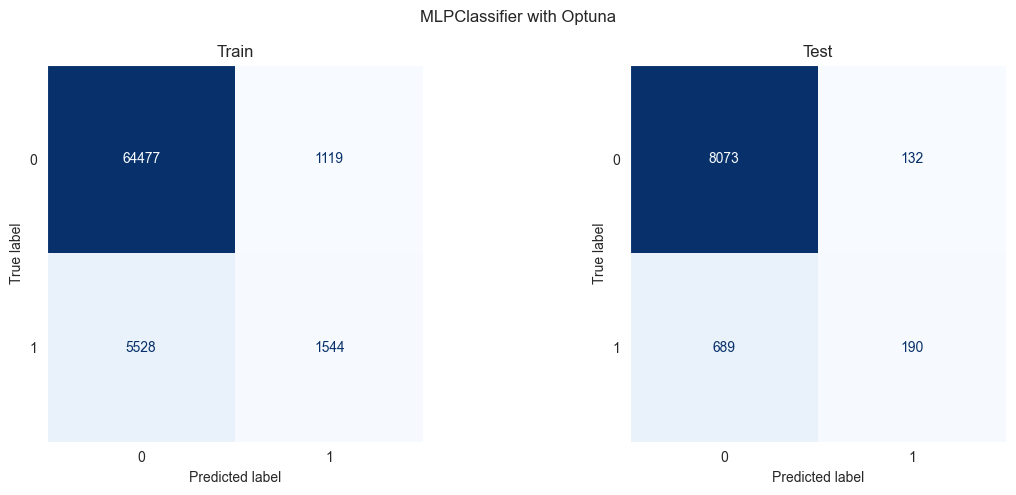

In [12]:
make_graphic(model, "MLPClassifier with Optuna")

In [13]:
print(f"Архитектура сети: {model.hidden_layer_sizes}")

print(f"Количество слоев: {model.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in model.coefs_]}")

Архитектура сети: (50, 50)
Количество слоев: 4
Количество весов (коэффициентов): [(3, 50), (50, 50), (50, 1)]



* **Входной слой**: 3 нейрона.
* **Первый скрытый слой**: 50 нейронов.
* **Второй скрытый слой**: 50 нейронов.
* **Выходной слой**: 1 нейрон (результат регрессии).


Text(0, 0.5, 'Loss')

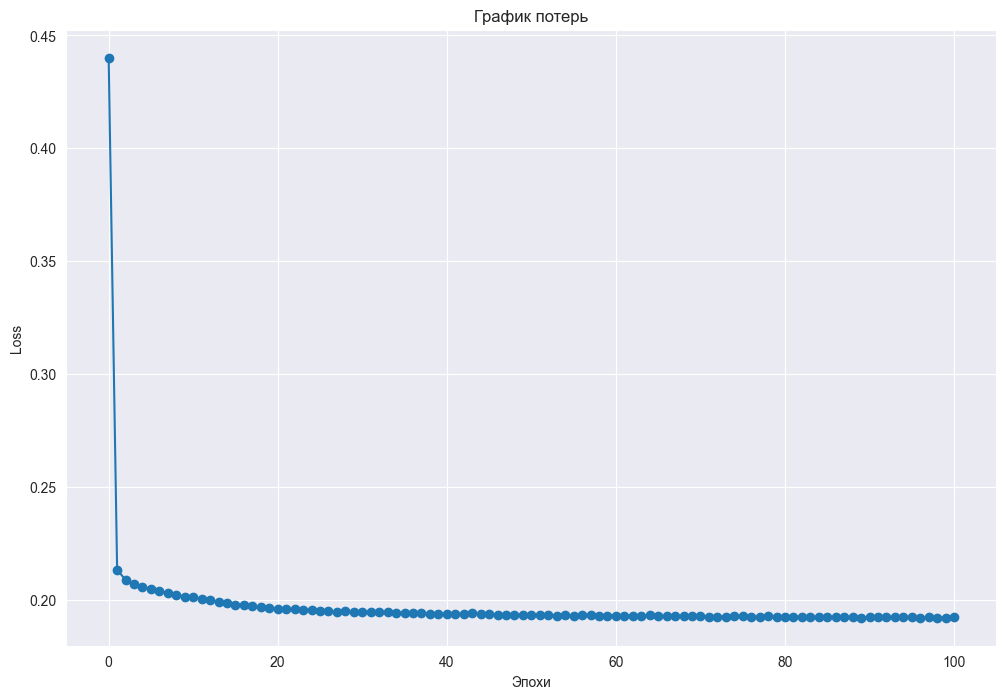

In [14]:
plt.figure(figsize=(12, 8))
plt.plot(model.loss_curve_, marker='o')
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss")

Модели удается найти оптимальные параметры меньше, чем за 20 эпох, так как начиная с этой эпохи величина ошибки практически не изменяется.

### RandomizedSearchCV

In [15]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'hidden_layer_sizes': [(100,), (50, 50), (100, 50), (100, 100, 100)],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'activation': ['relu', 'tanh', 'logistic'],
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'learning_rate': ['constant', 'adaptive'],
}

mlp = MLPClassifier(max_iter=1000)

rs = RandomizedSearchCV(estimator=mlp,
                        param_distributions=param_dist,
                        n_jobs=-1,
                        cv=3,
                        scoring="f1",
                        verbose=3)

rs.fit(X_train, y_train)
input_into_table("MLPClassifier", "RandomizedSearch", rs.best_estimator_, X_train, y_train, X_test, y_test)
table

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier,Optuna,0.32,0.9085,0.5798,0.2162,0.32,0.9096,0.5901,0.2162,101,adam
1,MLPClassifier,RandomizedSearch,0.21,0.9101,0.7373,0.1013,0.18,0.9098,0.7542,0.1013,83,adam


Для этой модели характерен более высокий precision (0.7542) в сравнении с предыдущей моделью, при этом значение recall уменьшилось до 0.1.

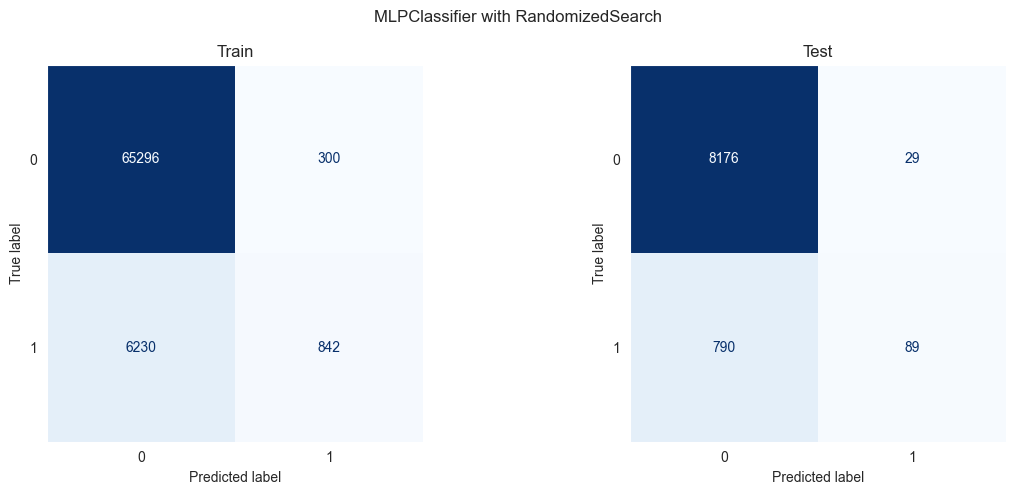

In [16]:
make_graphic(rs.best_estimator_, "MLPClassifier with RandomizedSearch")

Видим, что минимизурется ошибка первого рода (ложно-положительные срабатывания).

In [17]:
print(f"Архитектура сети: {rs.best_estimator_.hidden_layer_sizes}")

print(f"Количество слоев: {rs.best_estimator_.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in rs.best_estimator_.coefs_]}")

Архитектура сети: (100, 50)
Количество слоев: 4
Количество весов (коэффициентов): [(3, 100), (100, 50), (50, 1)]


Text(0, 0.5, 'Loss')

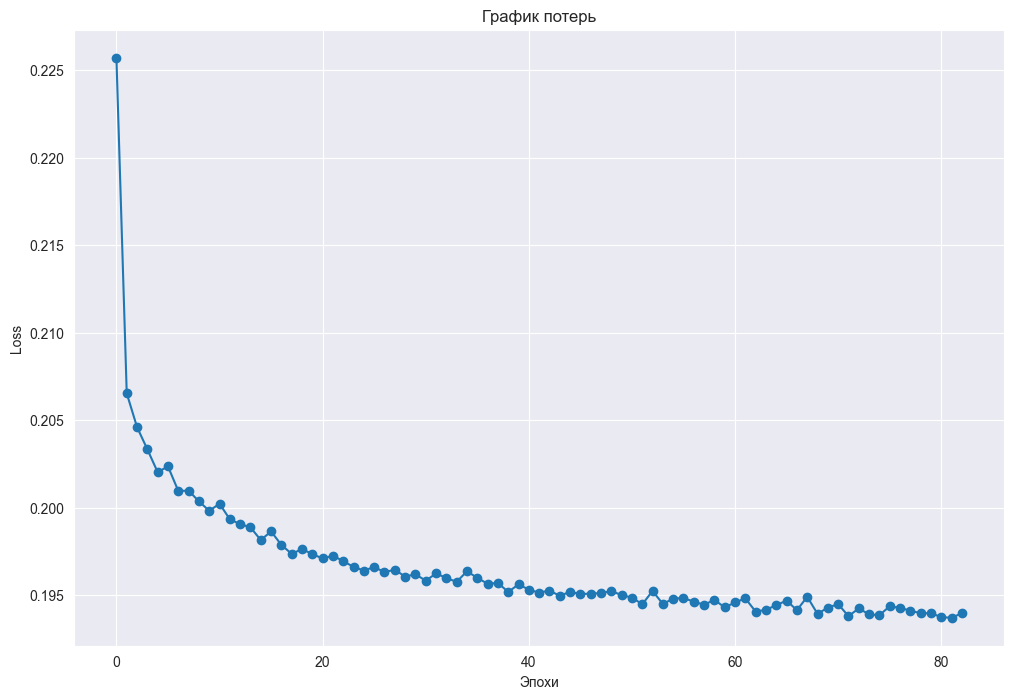

In [18]:
plt.figure(figsize=(12, 8))
plt.plot(rs.best_estimator_.loss_curve_, marker='o')
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss")

Начиная примерно с 60 эпохи ошибка практически не меняется. Стоит отметить, что величина ошибки на разных эпохах не равномерна, то есть в некоторых эпохах она возрастает, а в некоторых снова понижается, но на небольшую величину.

### Hyperport

In [20]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import numpy as np

layers = [(100,), (50, 50), (100, 50), (100, 100, 100)]
solvers = ['adam', 'sgd', 'lbfgs']
activations = ['relu', 'tanh']
learning_rates = ['constant', 'adaptive']

space = {
    'hidden_layer_sizes': hp.choice('hidden_layer_sizes', layers),
    'solver': hp.choice('solver', solvers),
    'activation': hp.choice('activation', activations),
    'alpha': hp.loguniform('alpha', np.log(1e-5), np.log(1e-2)),
    'learning_rate': hp.choice('learning_rate', learning_rates),
}

def objective(params):
    model = MLPClassifier(**params, max_iter=2000, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='r2').mean()
    return {'loss': -score, 'status': STATUS_OK}

trials = Trials()
best_indices = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=15, trials=trials)

best_params = {
    'hidden_layer_sizes': layers[best_indices['hidden_layer_sizes']],
    'solver': solvers[best_indices['solver']],
    'activation': activations[best_indices['activation']],
    'alpha': best_indices['alpha'],
    'learning_rate': learning_rates[best_indices['learning_rate']],
}


best_model_hyperopt = MLPClassifier(**best_params, max_iter=2000, random_state=42).fit(X_train, y_train)
input_into_table("MLPClassifier", "Hyperopt", best_model_hyperopt, X_train, y_train, X_test, y_test)

print("Лучшие параметры Hyperopt:", best_params)

100%|██████████| 15/15 [10:15<00:00, 41.06s/trial, best loss: 0.018209257147829245]
Лучшие параметры Hyperopt: {'hidden_layer_sizes': (100, 50), 'solver': 'adam', 'activation': 'relu', 'alpha': 0.0001335701241030737, 'learning_rate': 'adaptive'}


In [21]:
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier,Optuna,0.32,0.9085,0.5798,0.2162,0.32,0.9096,0.5901,0.2162,101,adam
1,MLPClassifier,RandomizedSearch,0.21,0.9101,0.7373,0.1013,0.18,0.9098,0.7542,0.1013,83,adam
2,MLPClassifier,Hyperopt,0.28,0.9107,0.6515,0.1559,0.25,0.9104,0.6555,0.1559,85,adam


Значение метрики recall = 0.1559, а precision = 0.6555. Это лучше результата RandomSearch, но хуже Optuna.

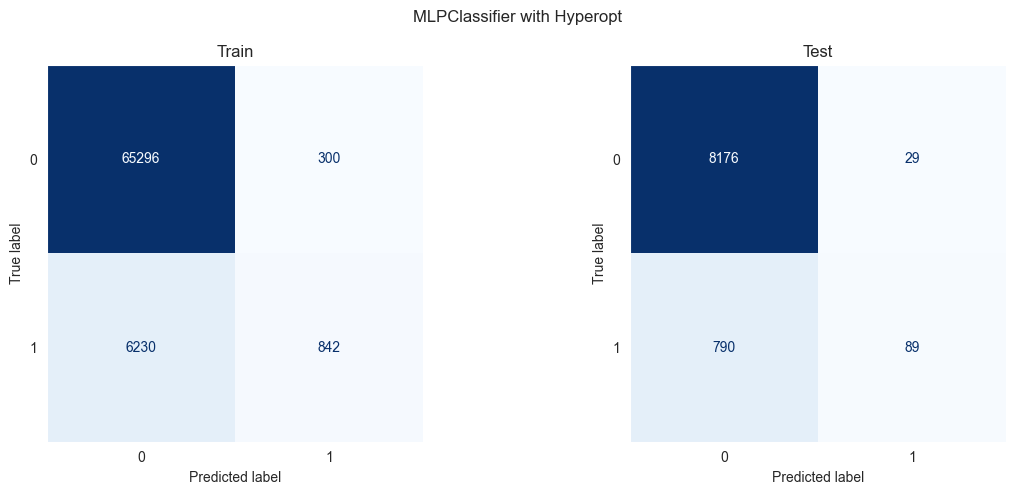

In [22]:
make_graphic(rs.best_estimator_, "MLPClassifier with Hyperopt")

Заметим, что количество ошибок первого рода (ложно-положительные срабатывания) меньше, чем ошибок второго рода (ложно-отрицательные срабатывания).

In [23]:
print(f"Архитектура сети: {best_model_hyperopt.hidden_layer_sizes}")

print(f"Количество слоев: {best_model_hyperopt.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in best_model_hyperopt.coefs_]}")

Архитектура сети: (100, 50)
Количество слоев: 4
Количество весов (коэффициентов): [(3, 100), (100, 50), (50, 1)]



* **Входной слой**: 3 нейрона.
* **Первый скрытый слой**: 100 нейронов.
* **Второй скрытый слой**: 50 нейронов.
* **Выходной слой**: 1 нейрон.


Text(0, 0.5, 'Loss')

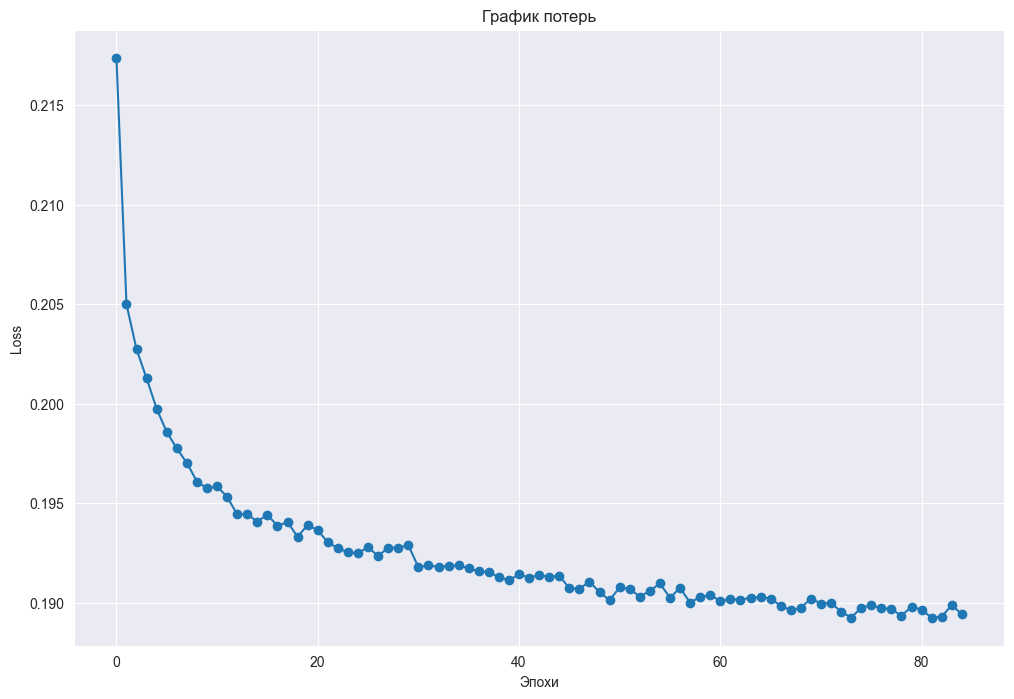

In [24]:
plt.figure(figsize=(12, 8))
plt.plot(best_model_hyperopt.loss_curve_, marker='o')
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss")

Видим, что начиная примерно с 50 эпохи ошибка перестает существенно уменьшаться.

## Keras

In [51]:
import keras
def input_into_table_keras(name, search_name, model, X_train, y_train, X_test, y_test, history):
    train_pred = (model.predict(X_train) > 0.5).astype("int32")
    test_pred = (model.predict(X_test) > 0.5).astype("int32")

    new_row = {
        'Classifier': name,
        'Search strategy': search_name,
        'Train_F1': round(f1_score(y_train, train_pred), 2),
        'Train_Accuracy': round(accuracy_score(y_train, train_pred), 4),
        'Train_Precision': round(precision_score(y_train, train_pred), 4),
        'Train_Recall': round(recall_score(y_train, train_pred), 4),
        'Test_F1': round(f1_score(y_test, test_pred), 2),
        'Test_Accuracy': round(accuracy_score(y_test, test_pred), 4),
        'Test_Precision': round(precision_score(y_test, test_pred), 4),
        'Test_Recall': round(recall_score(y_test, test_pred), 4),
        'Epochs': len(history.history['loss']),
        'Solver': model.optimizer.__class__.__name__
    }

    table.loc[len(table)] = new_row

optimizers_dict = {
    "adam": keras.optimizers.Adam,
    "sgd": keras.optimizers.SGD,
    "rmsprop": keras.optimizers.RMSprop,
}

In [53]:
def make_graphic_keras(model, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))


    y_train_pred = (model.predict(X_train) > 0.5).astype("int32")
    y_test_pred = (model.predict(X_test) > 0.5).astype("int32")


    cm_train = confusion_matrix(y_train, y_train_pred)
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
    disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title("Train")

    cm_test = confusion_matrix(y_test, y_test_pred)
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
    disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
    axes[1].set_title("Test")

    plt.suptitle(name)
    plt.tight_layout()
    plt.show()

In [54]:
def objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 5)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    activation = trial.suggest_categorical("activation", ["relu", "tanh", "elu", "sigmoid"])
    opt_name = trial.suggest_categorical("optimizer", list(optimizers_dict.keys()))
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X_train):
        X_t, X_v = X_train[train_idx], X_train[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = keras.Sequential()
        model.add(layers.Input(shape=(X_t.shape[1],)))

        for i in range(n_layers):
            num_hidden = trial.suggest_int(f"n_units_l{i}", 16, 512, log=True)
            model.add(layers.Dense(num_hidden, activation=activation))
            dropout_rate = trial.suggest_float(f"dropout_l{i}", 0.0, 0.3)
            model.add(layers.Dropout(dropout_rate))

        model.add(layers.Dense(1, activation="sigmoid"))

        optimizer = optimizers_dict[opt_name](learning_rate=learning_rate)
        model.compile(
            optimizer=optimizer,
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        model.fit(
            X_t, y_t,
            validation_data=(X_v, y_v),
            epochs=15,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=3
        )

        y_pred_probs = model.predict(X_v, verbose=0)
        y_pred = (y_pred_probs > 0.5).astype("int32")
        score = f1_score(y_v, y_pred)
        scores.append(score)

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)

print(f"Лучшая ошибка: {study.best_value}")
print(f"Параметры: {study.best_params}")



[I 2026-05-12 17:01:42,817] A new study created in memory with name: no-name-385ae31d-4bdc-4b3a-bc39-2c47ae0f7233


Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15


[I 2026-05-12 17:02:15,748] Trial 0 finished with value: 0.0 and parameters: {'n_layers': 3, 'learning_rate': 7.508239360117696e-05, 'activation': 'relu', 'optimizer': 'rmsprop', 'batch_size': 128, 'n_units_l0': 87, 'dropout_l0': 0.2487115332846966, 'n_units_l1': 25, 'dropout_l1': 0.11773052334285361, 'n_units_l2': 48, 'dropout_l2': 0.22046261007054713}. Best is trial 0 with value: 0.0.


Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15


[I 2026-05-12 17:03:03,779] Trial 1 finished with value: 0.2615990397283339 and parameters: {'n_layers': 3, 'learning_rate': 0.0012262278459235652, 'activation': 'tanh', 'optimizer': 'rmsprop', 'batch_size': 64, 'n_units_l0': 28, 'dropout_l0': 0.1428589869737067, 'n_units_l1': 20, 'dropout_l1': 0.2758030950713501, 'n_units_l2': 27, 'dropout_l2': 0.03305344881931932}. Best is trial 1 with value: 0.2615990397283339.


...

Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15


[I 2026-05-12 17:05:09,882] Trial 3 finished with value: 0.0 and parameters: {'n_layers': 2, 'learning_rate': 5.516394414483566e-05, 'activation': 'sigmoid', 'optimizer': 'adam', 'batch_size': 32, 'n_units_l0': 40, 'dropout_l0': 0.1866793062359405, 'n_units_l1': 21, 'dropout_l1': 0.2559080771190007}. Best is trial 1 with value: 0.2615990397283339.


Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15


[I 2026-05-12 17:05:54,432] Trial 4 finished with value: 0.23950315223306498 and parameters: {'n_layers': 1, 'learning_rate': 0.0012354218073087554, 'activation': 'relu', 'optimizer': 'rmsprop', 'batch_size': 64, 'n_units_l0': 217, 'dropout_l0': 0.04320866894050964}. Best is trial 1 with value: 0.2615990397283339.


Лучшая ошибка: 0.2615990397283339
Параметры: {'n_layers': 3, 'learning_rate': 0.0012262278459235652, 'activation': 'tanh', 'optimizer': 'rmsprop', 'batch_size': 64, 'n_units_l0': 28, 'dropout_l0': 0.1428589869737067, 'n_units_l1': 20, 'dropout_l1': 0.2758030950713501, 'n_units_l2': 27, 'dropout_l2': 0.03305344881931932}


In [55]:
import keras
params = study.best_params
model = keras.Sequential()
model.add(layers.Input(shape=(X_train.shape[1],)))


for i in range(params["n_layers"]):
    model.add(layers.Dense(
        params[f"n_units_l{i}"],
        activation=params["activation"]
    ))
    if f"dropout_l{i}" in params:
        model.add(layers.Dropout(params[f"dropout_l{i}"]))

model.add(layers.Dense(1, activation="sigmoid"))

model.compile(
    optimizer=optimizers_dict[params["optimizer"]](learning_rate=params["learning_rate"]),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=study.best_params["batch_size"],
    verbose=2
)

Epoch 1/25
1136/1136 - 2s - 1ms/step - accuracy: 0.8986 - loss: 0.2257 - val_accuracy: 0.9021 - val_loss: 0.2087
Epoch 2/25
1136/1136 - 1s - 916us/step - accuracy: 0.9034 - loss: 0.2114 - val_accuracy: 0.9021 - val_loss: 0.2078
Epoch 3/25
1136/1136 - 1s - 921us/step - accuracy: 0.9038 - loss: 0.2102 - val_accuracy: 0.9048 - val_loss: 0.2062
Epoch 4/25
1136/1136 - 1s - 944us/step - accuracy: 0.9048 - loss: 0.2091 - val_accuracy: 0.9030 - val_loss: 0.2095
Epoch 5/25
1136/1136 - 1s - 918us/step - accuracy: 0.9052 - loss: 0.2082 - val_accuracy: 0.9077 - val_loss: 0.2053
Epoch 6/25
1136/1136 - 1s - 928us/step - accuracy: 0.9051 - loss: 0.2076 - val_accuracy: 0.9062 - val_loss: 0.2059
Epoch 7/25
1136/1136 - 1s - 917us/step - accuracy: 0.9050 - loss: 0.2072 - val_accuracy: 0.9058 - val_loss: 0.2045
Epoch 8/25
1136/1136 - 1s - 983us/step - accuracy: 0.9054 - loss: 0.2068 - val_accuracy: 0.9074 - val_loss: 0.2041
Epoch 9/25
1136/1136 - 1s - 1ms/step - accuracy: 0.9052 - loss: 0.2060 - val_accur

In [56]:
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_61 (Dense)                │ (None, 28)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 20)             │           580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 27)             │           567 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 27)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 1)              │            28 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,576 (10.07 KB)

 Trainable params: 1,287 (5.03 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,289 (5.04 KB)

* **Входной слой**: 3 нейрона.
* **Первый скрытый слой**: 138 нейронов.
* **Второй скрытый слой**: 425 нейронов.
* **Третий скрытый слой**: 437 нейронов.
* **Выходной слой**: 1 нейрон.

In [57]:
input_into_table_keras("FCNN (Keras)", "Optuna", model, X_train, y_train, X_test, y_test, history)

2271/2271 ━━━━━━━━━━━━━━━━━━━━ 1s 464us/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step


Text(0, 0.5, 'Loss')

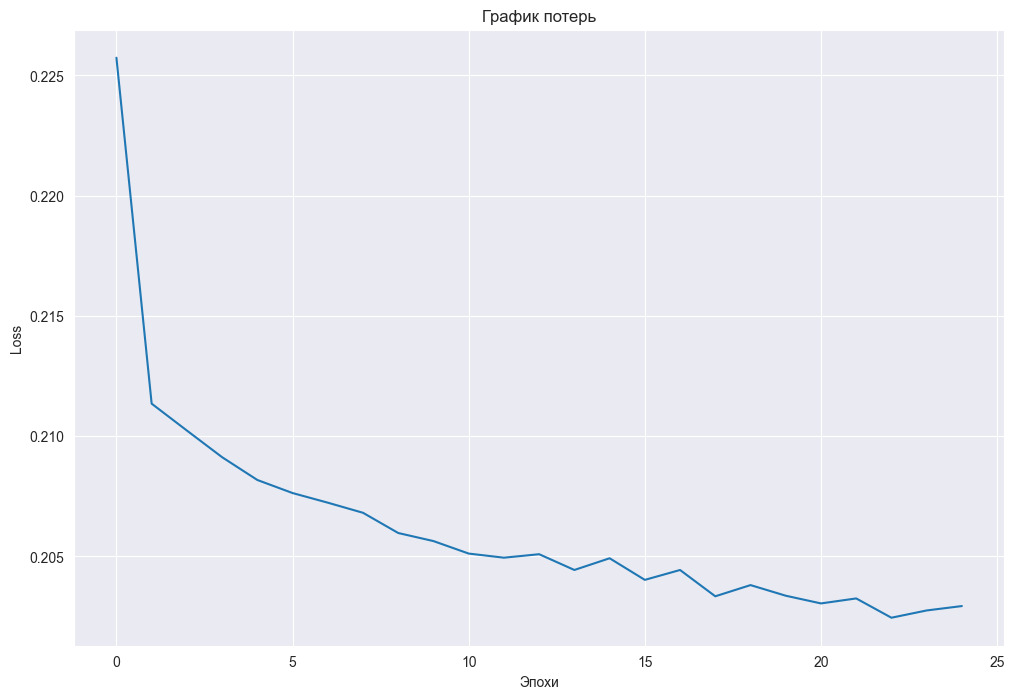

In [58]:
plt.figure(figsize=(12, 8))
plt.plot(history.history['loss'])
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss")

Заметим, что примерно с 10 эпохи ошибка перестает существенно меняться.

In [61]:
table[:4]

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier,Optuna,0.32,0.9085,0.5798,0.2162,0.320,0.9096,0.5901,0.2162,101,adam
1,MLPClassifier,RandomizedSearch,0.21,0.9101,0.7373,0.1013,0.180,0.9098,0.7542,0.1013,83,adam
2,MLPClassifier,Hyperopt,0.28,0.9107,0.6515,0.1559,0.250,0.9104,0.6555,0.1559,85,adam
3,FCNN (Keras),Optuna,0.13,0.9072,0.7448,0.0700,0.122,0.9081,0.8056,0.0660,25,RMSprop


Модель, построенная с помощью API Keras, обладает наиболее высоким значением Precision (0.8056), но наиболее низким recall (0.066).

2271/2271 ━━━━━━━━━━━━━━━━━━━━ 1s 510us/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step


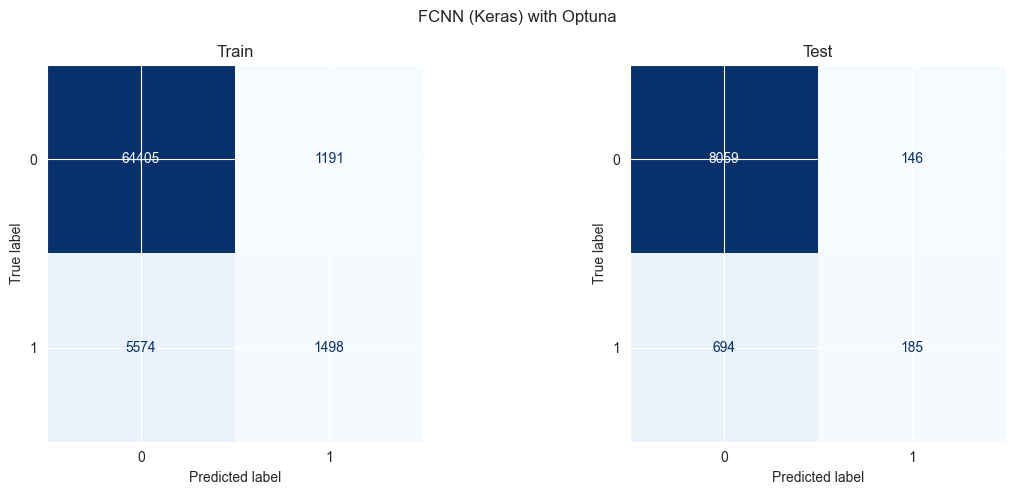

In [62]:
make_graphic_keras(model, "FCNN (Keras) with Optuna")

Заметим, что эта модель минизирует количество ошибок первого рода (то есть ложно - положительные срабатывания).

### KerasTuner

In [63]:
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    activation_choice = hp.Choice("activation", ["relu", "tanh", "elu", "sigmoid"])

    for i in range(hp.Int("n_layers", 1, 5)):
        model.add(layers.Dense(
            units=hp.Int(f"units_{i}", min_value=32, max_value=512, step=32),
            activation=activation_choice
        ))
        if hp.Boolean("dropout"):
            model.add(layers.Dropout(0.2))

    model.add(layers.Dense(1, activation="sigmoid"))

    lr = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer_name = hp.Choice("optimizer", list(optimizers_dict.keys()))
    optimizer = optimizers_dict[optimizer_name](learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [64]:
import keras_tuner as kt
import keras
from keras import layers

tuner = kt.BayesianOptimization(
    build_model,
    objective="val_accuracy",
    max_trials=5,
    overwrite=True,
    project_name="classification_tuning"
)

tuner.search(
    X_train,
    y_train,
    epochs=15,
    validation_data=(X_val, y_val),
    verbose=2,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)]
)

best_model = tuner.get_best_models(num_models=1)[0]
best_params = tuner.get_best_hyperparameters(num_trials=1)[0]


Trial 5 Complete [00h 00m 57s]
val_accuracy: 0.9021356105804443

Best val_accuracy So Far: 0.9085204601287842
Total elapsed time: 00h 03m 28s


C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [82]:
history = best_model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    verbose=2
)

input_into_table_keras(
    name="FCNN (Keras)",
    search_name="KerasTuner (Bayesian)",
    model=best_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    history=history
)


Epoch 1/50
2271/2271 - 11s - 5ms/step - accuracy: 0.9064 - loss: 0.2058 - val_accuracy: 0.9066 - val_loss: 0.2085
Epoch 2/50
2271/2271 - 11s - 5ms/step - accuracy: 0.9058 - loss: 0.2061 - val_accuracy: 0.9090 - val_loss: 0.1983
Epoch 3/50
2271/2271 - 19s - 9ms/step - accuracy: 0.9063 - loss: 0.2053 - val_accuracy: 0.9090 - val_loss: 0.1988
Epoch 4/50
2271/2271 - 10s - 4ms/step - accuracy: 0.9067 - loss: 0.2076 - val_accuracy: 0.9062 - val_loss: 0.1999
Epoch 5/50
2271/2271 - 10s - 4ms/step - accuracy: 0.9071 - loss: 0.2066 - val_accuracy: 0.9074 - val_loss: 0.2004
Epoch 6/50
2271/2271 - 10s - 4ms/step - accuracy: 0.9061 - loss: 0.2070 - val_accuracy: 0.9092 - val_loss: 0.1995
Epoch 7/50
2271/2271 - 10s - 4ms/step - accuracy: 0.9063 - loss: 0.2066 - val_accuracy: 0.9073 - val_loss: 0.2013
Epoch 8/50
2271/2271 - 10s - 4ms/step - accuracy: 0.9057 - loss: 0.2071 - val_accuracy: 0.9086 - val_loss: 0.2070
Epoch 9/50
2271/2271 - 10s - 5ms/step - accuracy: 0.9057 - loss: 0.2069 - val_accuracy: 

Text(0, 0.5, 'Loss')

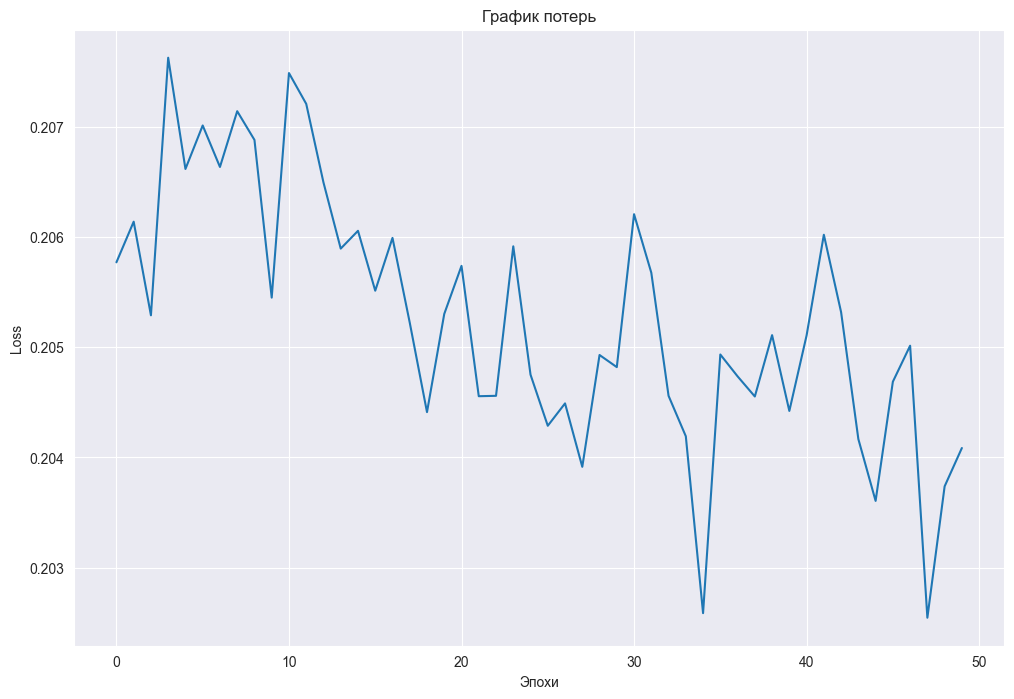

In [84]:
plt.figure(figsize=(12, 8))
plt.plot(history.history['loss'])
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss")

Видим, что график потерь выглядит как ломаная. Есть некоторая общая тенденция на снижение ошибки, но она непостоянна. Для этого алгоритма стоит увеличить количество эпох при обучении.

2271/2271 ━━━━━━━━━━━━━━━━━━━━ 1s 541us/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step


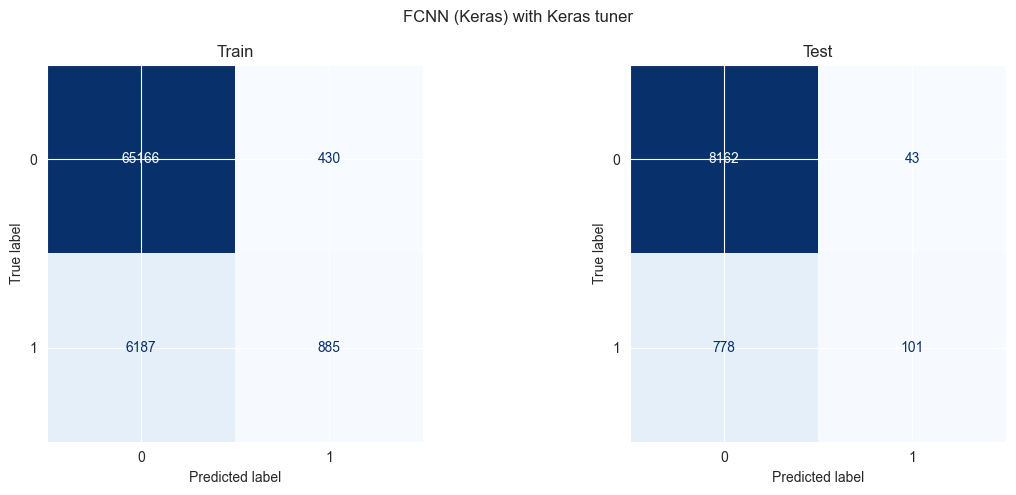

In [85]:
make_graphic_keras(best_model, "FCNN (Keras) with Keras tuner")

In [89]:
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier,Optuna,0.32,0.9085,0.5798,0.2162,0.320,0.9096,0.5901,0.2162,101,adam
1,MLPClassifier,RandomizedSearch,0.21,0.9101,0.7373,0.1013,0.180,0.9098,0.7542,0.1013,83,adam
2,MLPClassifier,Hyperopt,0.28,0.9107,0.6515,0.1559,0.250,0.9104,0.6555,0.1559,85,adam
3,FCNN (Keras),Optuna,0.13,0.9072,0.7448,0.0700,0.122,0.9081,0.8056,0.0660,25,RMSprop
4,FCNN (Keras),KerasTuner (Bayesian),0.21,0.9090,0.6846,0.1206,0.200,0.9102,0.7234,0.1160,25,RMSprop


Эта модель показала f1 = 0.2 на тестовой выборке. Стоит отметить, что precision = 0.7234, а recall = 0.1160. Есть некоторая закономерность в том, что при обучении моделей с нейросетевым подходом на этих данных precision значительно превосходит recall. Возможно, что это связано с подходом балансировки.

In [90]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 448)            │        14,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 192)            │        86,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,076 (887.02 KB)

 Trainable params: 113,537 (443.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 113,539 (443.52 KB)

* **Входной слой**: 3 нейрона .
* **Первый скрытый слой**: 32 нейрона.
* **Второй скрытый слой**: 448 нейронов.
* **Третий скрытый слой**: 192 нейрона.
* **Четвертый скрытый слой**: 64 нейрона.
* **Выходной слой**: 1 нейрон.

In [91]:
from ray import tune
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import numpy as np

def train_model_ray(config):
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_results = []
    opt_map = {
        "adam": tf.keras.optimizers.Adam,
        "sgd": tf.keras.optimizers.SGD,
        "rmsprop": tf.keras.optimizers.RMSprop
    }

    for train_idx, val_idx in kf.split(X_train):
        X_t, X_v = X_train[train_idx], X_train[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = Sequential()
        model.add(layers.Input(shape=(X_t.shape[1],)))

        for i in range(config["n_layers"]):
            model.add(layers.Dense(units=config[f"units_{i}"], activation=config["activation"]))
            model.add(layers.Dropout(config["dropout_rate"]))

        model.add(layers.Dense(1, activation="sigmoid"))

        optimizer = opt_map[config["optimizer"]](learning_rate=config["lr"])
        model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

        model.fit(X_t, y_t, epochs=30, batch_size=32, validation_data=(X_v, y_v), verbose=0)

        y_pred = (model.predict(X_v, verbose=0) > 0.5).astype("int32")
        fold_results.append(f1_score(y_v, y_pred))

    tune.report({"mean_f1": float(np.mean(fold_results))})

search_space = {
    "n_layers": tune.randint(1, 4),
    "activation": tune.choice(["relu", "tanh", "sigmoid"]),
    "dropout_rate": tune.uniform(0.0, 0.3),
    "lr": tune.loguniform(1e-4, 1e-2),
    "optimizer": tune.choice(["adam", "sgd"]),
}

for i in range(4):
    search_space[f"units_{i}"] = tune.qrandint(32, 256, 32)

tuner = tune.Tuner(
    train_model_ray,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        metric="mean_f1",
        mode="max",
        num_samples=15
    )
)

results = tuner.fit()
print("Лучшие параметры:", results.get_best_result().config)


2026-05-12 17:33:45,544	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-12_16-04-09_800202_14172\artifacts\2026-05-12_17-33-45\train_model_ray_2026-05-12_17-33-45\driver_artifacts\train_model_ray_6f658_00000_0_activation=sigmoid,dropout_rate=0.1623,lr=0.0013,n_layers=2,optimizer=adam,units_0=64,units_1=192,un_2026-05-12_17-33-45
2026-05-12 17:33:45,708	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-12_16-04-09_800202_14172\artifacts\2026-05-12_17-33-45\train_model_ray_2026-05-12_17-33-45\driver_artifacts\train_model_ray_6f658_00000_0_activation=sigmoid,dropout_rate=0.1623,lr=0.0013,n_layers=2,optimizer=adam,units_0=64,units_1=192,un_2026-05-12_17-33-45
2026-05-12 17:

2026-05-12 17:34:35,578	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-12_16-04-09_800202_14172\artifacts\2026-05-12_17-33-45\train_model_ray_2026-05-12_17-33-45\driver_artifacts\train_model_ray_6f658_00005_5_activation=relu,dropout_rate=0.0617,lr=0.0100,n_layers=3,optimizer=sgd,units_0=256,units_1=64,units__2026-05-12_17-33-45
2026-05-12 17:34:35,594	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-12_16-04-09_800202_14172\artifacts\2026-05-12_17-33-45\train_model_ray_2026-05-12_17-33-45\driver_artifacts\train_model_ray_6f658_00001_1_activation=relu,dropout_rate=0.2346,lr=0.0001,n_layers=1,optimizer=sgd,units_0=160,units_1=96,units__2026-05-12_17-33-45
2026-05-12 17:

Лучшие параметры: {'n_layers': 3, 'activation': 'tanh', 'dropout_rate': 0.26893422426995434, 'lr': 0.00028416605270238003, 'optimizer': 'adam', 'units_0': 256, 'units_1': 32, 'units_2': 160, 'units_3': 192}


In [92]:
config = results.get_best_result().config
model = keras.Sequential()
model.add(layers.Input(shape=(X_train.shape[1],)))

for i in range(config["n_layers"]):
    model.add(layers.Dense(
        units=config[f"units_{i}"],
        activation=config["activation"]
    ))
    model.add(layers.Dropout(config["dropout_rate"]))

model.add(layers.Dense(1, activation="sigmoid"))

optimizer = optimizers_dict[config["optimizer"]](learning_rate=config["lr"])
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

input_into_table_keras(
    name="FCNN (Keras)",
    search_name="Ray Tune",
    model=model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    history=history
)


Epoch 1/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8889 - loss: 0.2599 - val_accuracy: 0.9021 - val_loss: 0.2103
Epoch 2/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8966 - loss: 0.2239 - val_accuracy: 0.9021 - val_loss: 0.2085
Epoch 3/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8963 - loss: 0.2201 - val_accuracy: 0.9021 - val_loss: 0.2064
Epoch 4/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9027 - loss: 0.2123 - val_accuracy: 0.9025 - val_loss: 0.2058
Epoch 5/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9007 - loss: 0.2138 - val_accuracy: 0.9063 - val_loss: 0.2055
Epoch 6/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9031 - loss: 0.2099 - val_accuracy: 0.9055 - val_loss: 0.2046
Epoch 7/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9031 - loss: 0.2101 - val_accuracy: 0.9046 - val_loss: 0.2059
Epoch 8/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9044 - loss: 0.2080 - 

In [93]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 160)            │         5,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,069 (172.15 KB)

 Trainable params: 14,689 (57.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 29,380 (114.77 KB)

* **Входной слой**: 3 нейрона.
* **Первый скрытый слой**: 256 нейронов.
* **Второй скрытый слой**: 32 нейрона.
* **Третий скрытый слой**: 160 нейронов.
* **Выходной слой**: 1 нейрон (результат регрессии).

In [94]:
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier,Optuna,0.32,0.9085,0.5798,0.2162,0.320,0.9096,0.5901,0.2162,101,adam
1,MLPClassifier,RandomizedSearch,0.21,0.9101,0.7373,0.1013,0.180,0.9098,0.7542,0.1013,83,adam
2,MLPClassifier,Hyperopt,0.28,0.9107,0.6515,0.1559,0.250,0.9104,0.6555,0.1559,85,adam
3,FCNN (Keras),Optuna,0.13,0.9072,0.7448,0.0700,0.122,0.9081,0.8056,0.0660,25,RMSprop
4,FCNN (Keras),KerasTuner (Bayesian),0.21,0.9090,0.6846,0.1206,0.200,0.9102,0.7234,0.1160,25,RMSprop
5,FCNN (Keras),Ray Tune,0.25,0.9083,0.6119,0.1581,0.250,0.9096,0.6368,0.1536,50,Adam


Стоит отметить, что модель ray_tune показала одни из лучших результатов по f1 метрике (0.25), наравне с hyperport. При этом значение precision = 0.6368, а recall = 0.1536.

Text(0, 0.5, 'Loss (MSE)')

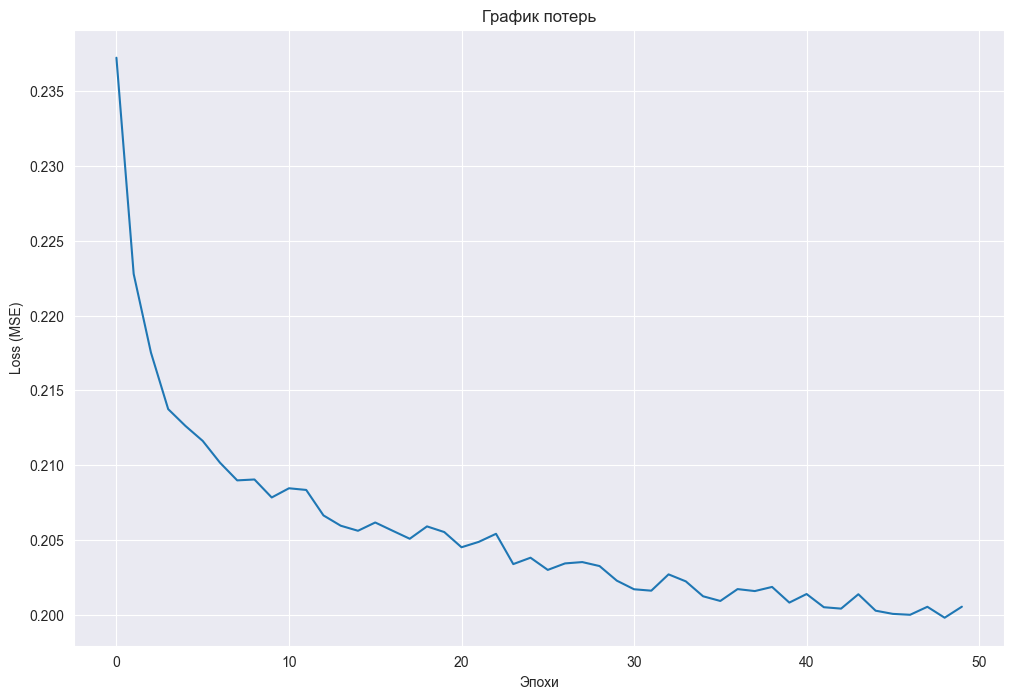

In [95]:
plt.figure(figsize=(12, 8))
plt.plot(history.history['loss'])
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss (MSE)")

Видим, что с применением 50 эпох при обучении ошибка идет на постоянное снижение уже с 30 эпохи.

2271/2271 ━━━━━━━━━━━━━━━━━━━━ 1s 458us/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step


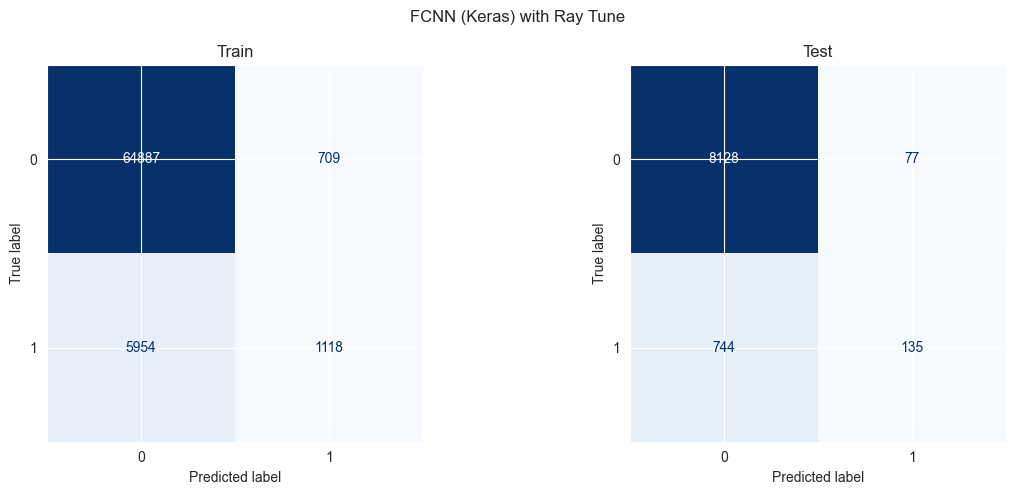

In [96]:
make_graphic_keras(model, "FCNN (Keras) with Ray Tune")

Можно заметить, что минимизируется ошибка первого рода (то есть ложно положительные срабатывания), что подтверждается высоким precision.

## Вывод

In [97]:
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier,Optuna,0.32,0.9085,0.5798,0.2162,0.320,0.9096,0.5901,0.2162,101,adam
1,MLPClassifier,RandomizedSearch,0.21,0.9101,0.7373,0.1013,0.180,0.9098,0.7542,0.1013,83,adam
2,MLPClassifier,Hyperopt,0.28,0.9107,0.6515,0.1559,0.250,0.9104,0.6555,0.1559,85,adam
3,FCNN (Keras),Optuna,0.13,0.9072,0.7448,0.0700,0.122,0.9081,0.8056,0.0660,25,RMSprop
4,FCNN (Keras),KerasTuner (Bayesian),0.21,0.9090,0.6846,0.1206,0.200,0.9102,0.7234,0.1160,25,RMSprop
5,FCNN (Keras),Ray Tune,0.25,0.9083,0.6119,0.1581,0.250,0.9096,0.6368,0.1536,50,Adam


Прежде всего стоит отметить, что нейросетевой подход не достаточно подходит для этих данных, так как с его помощью были получены низкие метрики. Максимальным f1 (0.32) обладает модель MLPClassifier, построенная с помощью Optuna. Она же обладает наиболее высоким recall (0.2162).

Лучшие результаты метрик были получены при построении ансамблевых моделей (f1 = 0.5) и при использовании наивной байесовской модели (recall = 0.9931).

In [109]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

data = pd.read_csv("datasets/neo.csv", index_col = 0)
X, y = data.drop("hazardous", axis=1), data["hazardous"]

pipeline = Pipeline([
    ('minmax', MinMaxScaler()),
    ('scaler', StandardScaler()),
    ('umap', UMAP(n_components=3, random_state=42)),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(50, 50),
        solver='adam',
        activation='relu',
        alpha=0.001408268688175312,
        learning_rate='constant',
        learning_rate_init=0.00037123954916206667,
        random_state=42,
    ))
])
pipeline.fit(X, y)

C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Pipeline(steps=[('minmax', MinMaxScaler()), ('scaler', StandardScaler()),
                ('umap',
                 UMAP(n_components=3, n_jobs=1, random_state=42, tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True})),
                ('mlp',
                 MLPClassifier(alpha=0.001408268688175312,
                               hidden_layer_sizes=(50, 50),
                               learning_rate_init=0.00037123954916206667,
                               random_state=42))])

In [111]:
sample_data = single_object = {
    'est_diameter_min': [0.127],
    'est_diameter_max': [0.284],
    'relative_velocity': [52340.5],
    'miss_distance': [4500000.0],
    'absolute_magnitude': [21.5]}

sample_df = pd.DataFrame(single_object)

prediction = pipeline.predict(sample_df)
print(f"Результат предсказания: {prediction[0]}")

Результат предсказания: 0


Модель посчитала объект неопасным. Так как значение recall у модели низкое, то объект вполне мог оказаться опасным в действительности.